In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
import joblib

In [2]:
df = pd.read_csv(r"D:\Downloads\mail_data.csv")

In [3]:
print(df)

     Category                                            Message
0         ham  Go until jurong point, crazy.. Available only ...
1         ham                      Ok lar... Joking wif u oni...
2        spam  Free entry in 2 a wkly comp to win FA Cup fina...
3         ham  U dun say so early hor... U c already then say...
4         ham  Nah I don't think he goes to usf, he lives aro...
...       ...                                                ...
5567     spam  This is the 2nd time we have tried 2 contact u...
5568      ham               Will ü b going to esplanade fr home?
5569      ham  Pity, * was in mood for that. So...any other s...
5570      ham  The guy did some bitching but I acted like i'd...
5571      ham                         Rofl. Its true to its name

[5572 rows x 2 columns]


In [4]:
data = df.where((pd.notnull(df)), " " )

In [5]:
data.head(10)

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [7]:
data.shape

(5572, 2)

In [8]:
data['Category'] = data['Category'].map({'spam': 0, 'ham': 1})

In [9]:
X = data['Message']
Y = data['Category']

In [10]:
print(X)

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                 Will ü b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: Message, Length: 5572, dtype: object


In [11]:
print(Y)

0       1
1       1
2       0
3       1
4       1
       ..
5567    0
5568    1
5569    1
5570    1
5571    1
Name: Category, Length: 5572, dtype: int64


In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=3, stratify=Y
)

In [13]:
print(X.shape)
print(X_train.shape)
print(X_test.shape)

(5572,)
(4457,)
(1115,)


In [14]:
feature_extraction = TfidfVectorizer(min_df=1, stop_words='english', lowercase=True)

X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)

Y_train = Y_train.astype('int')
Y_test = Y_test.astype('int')

In [15]:
print(X_train)

3501    Dorothy@kiefer.com (Bank of Granite issues Str...
617     He like not v shock leh. Cos telling shuhui is...
475     Nice line said by a broken heart- Plz don't cu...
5535    I know you are thinkin malaria. But relax, chi...
4747           Orh i tot u say she now still dun believe.
                              ...                        
4402         Many times we lose our best ones bcoz we are
3615                                         Ok c ü then.
4763                      Me too! Have a lovely night xxx
4339                          Yes when is the appt again?
1827    Dude. What's up. How Teresa. Hope you have bee...
Name: Message, Length: 4457, dtype: object


In [16]:
print(X_train_features)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 34678 stored elements and shape (4457, 7493)>
  Coords	Values
  (0, 2353)	0.28101404009316056
  (0, 3806)	0.28101404009316056
  (0, 1857)	0.17073786814794129
  (0, 1193)	0.22908400928709988
  (0, 3113)	0.28101404009316056
  (0, 3627)	0.25144905621529934
  (0, 6330)	0.24059246244542992
  (0, 1540)	0.17407870571957915
  (0, 2644)	0.28101404009316056
  (0, 5029)	0.17467075796896542
  (0, 4306)	0.26793132631329497
  (0, 421)	0.25144905621529934
  (0, 4557)	0.28101404009316056
  (0, 6468)	0.26793132631329497
  (0, 1657)	0.28101404009316056
  (0, 0)	0.23628394623676158
  (1, 3982)	0.4167622750027118
  (1, 5911)	0.2761926296686631
  (1, 3941)	0.20702870014136815
  (1, 1969)	0.1749293187718031
  (1, 6553)	0.4722950153731612
  (1, 5947)	0.24356944504246256
  (1, 3948)	0.2761926296686631
  (1, 2113)	0.1985161464110967
  (1, 3828)	0.13684128003316173
  :	:
  (4456, 5091)	0.1743505991070133
  (4456, 7339)	0.13767285254208542
  (4456, 24

In [17]:
model = LogisticRegression()

In [18]:
model.fit(X_train_features, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [19]:
prediction_on_training_data = model.predict(X_train_features)
accuracy_on_training_data = accuracy_score(Y_train, prediction_on_training_data)

In [20]:
print('Acc on training data : ', accuracy_on_training_data)

Acc on training data :  0.9667938074938299


In [21]:
prediction_on_test_data = model.predict(X_test_features)
accuracy_on_test_data = accuracy_score(Y_test, prediction_on_test_data)

In [22]:
print('acc on test data : ', accuracy_on_test_data)

acc on test data :  0.9713004484304932


In [23]:
models = {
    'Logistic Regression': model,
    'Naive Bayes': MultinomialNB(),
    'SVM (Linear)': SVC(kernel='linear', class_weight='balanced', probability=True),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}

In [24]:
from sklearn.metrics import make_scorer
spam_f1_scorer = make_scorer(f1_score, pos_label=0)

cv_results = {}

for name, m in models.items():
    scores = cross_val_score(m, X_train_features, Y_train, cv=5, scoring=spam_f1_scorer, n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:22s}: mean spam F1 = {scores.mean():.4f}  (+/- {scores.std():.4f})')

Logistic Regression   : mean spam F1 = 0.7066  (+/- 0.0488)
Naive Bayes           : mean spam F1 = 0.8527  (+/- 0.0452)
SVM (Linear)          : mean spam F1 = 0.9179  (+/- 0.0253)
Random Forest         : mean spam F1 = 0.8915  (+/- 0.0328)


In [25]:
results = []
fitted_models = {}

for name, m in models.items():
    m.fit(X_train_features, Y_train)
    fitted_models[name] = m
    preds = m.predict(X_test_features)

    # pos_label=0 because spam=0 in this notebook's encoding -- without this,
    # these functions silently score ham (label=1) as the positive class instead.
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(Y_test, preds),
        'Spam Precision': precision_score(Y_test, preds, pos_label=0),
        'Spam Recall': recall_score(Y_test, preds, pos_label=0),
        'Spam F1': f1_score(Y_test, preds, pos_label=0),
    })

results_df = pd.DataFrame(results).sort_values('Spam F1', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Spam Precision,Spam Recall,Spam F1
0,SVM (Linear),0.987444,0.985612,0.919463,0.951389
1,Random Forest,0.982960,1.000000,0.872483,0.931900
2,Logistic Regression,0.971300,0.991597,0.791946,0.880597
3,Naive Bayes,0.971300,1.000000,0.785235,0.879699


### Visualize the comparison

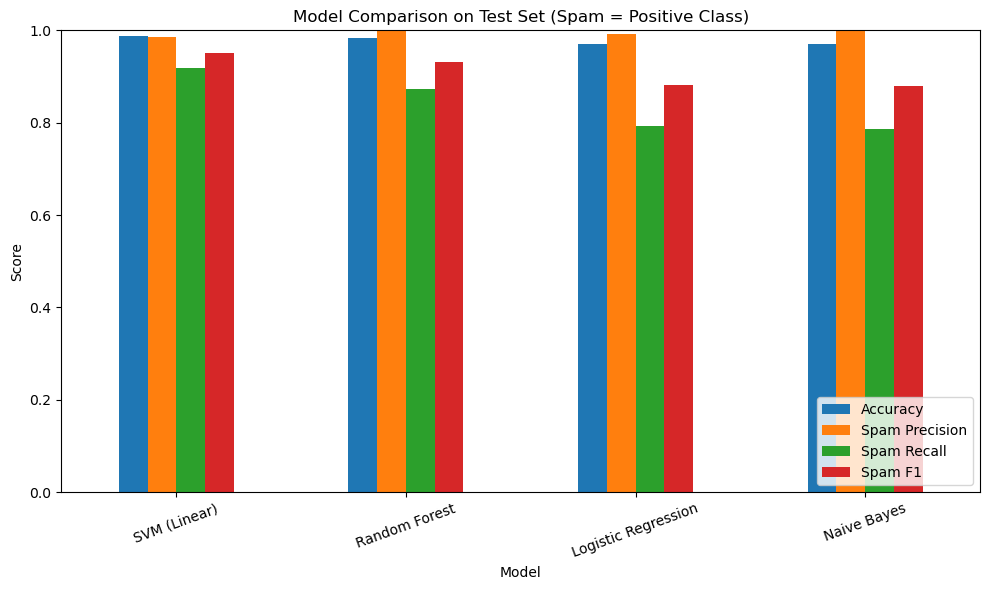

In [26]:
results_df.set_index('Model')[['Accuracy', 'Spam Precision', 'Spam Recall', 'Spam F1']].plot(
    kind='bar', figsize=(10, 6), ylim=(0, 1)
)
plt.title('Model Comparison on Test Set (Spam = Positive Class)')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

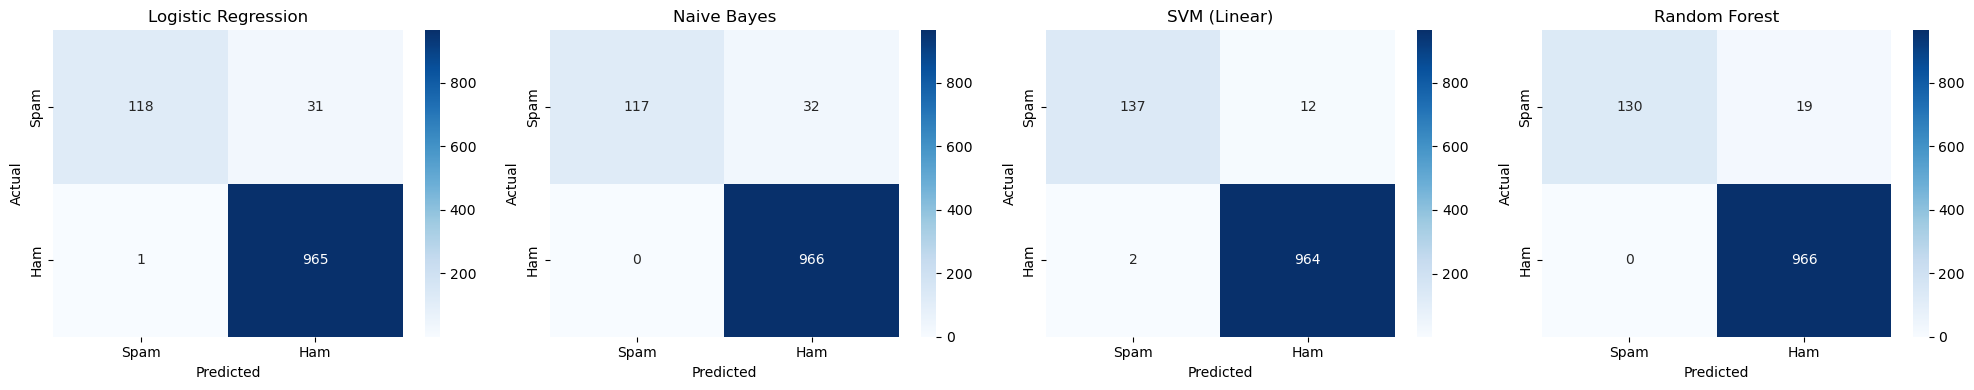

In [27]:
fig, axes = plt.subplots(1, len(fitted_models), figsize=(5 * len(fitted_models), 4))

for ax, (name, m) in zip(axes, fitted_models.items()):
    preds = m.predict(X_test_features)
    cm = confusion_matrix(Y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Spam', 'Ham'], yticklabels=['Spam', 'Ham'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score
roc_data = {}

for name, m in fitted_models.items():
    if hasattr(m, 'predict_proba'):
        spam_proba = m.predict_proba(X_test_features)[:, 0]
    else:
        # fallback for models without predict_proba (e.g. plain LinearSVC)
        spam_proba = -m.decision_function(X_test_features)
    fpr, tpr, _ = roc_curve(Y_test, spam_proba, pos_label=0)
    auc = roc_auc_score(1 - Y_test, spam_proba)
    roc_data[name] = (fpr, tpr, auc)
    print(f'{name:22s}: AUC = {auc:.4f}')

Logistic Regression   : AUC = 0.9924
Naive Bayes           : AUC = 0.9909
SVM (Linear)          : AUC = 0.9944
Random Forest         : AUC = 0.9903


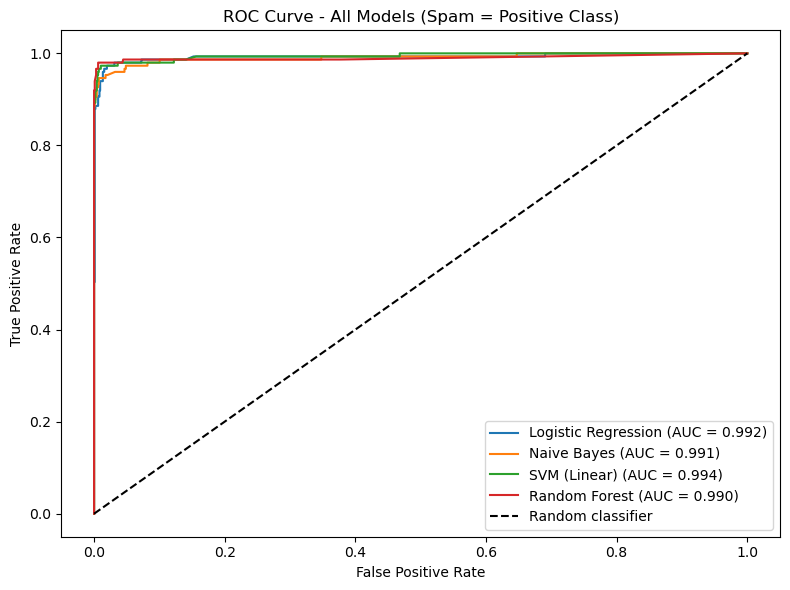

In [29]:
plt.figure(figsize=(8, 6))

for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.title('ROC Curve - All Models (Spam = Positive Class)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [30]:
best_model_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]

print(f'Best model: {best_model_name}\n')
print(classification_report(Y_test, best_model.predict(X_test_features), target_names=['Spam', 'Ham']))

Best model: SVM (Linear)

              precision    recall  f1-score   support

        Spam       0.99      0.92      0.95       149
         Ham       0.99      1.00      0.99       966

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



In [31]:
model_filename = f"spam_classifier_{best_model_name.replace(' ', '_').lower()}.joblib"
joblib.dump(best_model, model_filename)
joblib.dump(feature_extraction, 'tfidf_vectorizer.joblib')
print(f'Saved {best_model_name} to {model_filename}')
print('Saved TF-IDF vectorizer to tfidf_vectorizer.joblib')

Saved SVM (Linear) to spam_classifier_svm_(linear).joblib
Saved TF-IDF vectorizer to tfidf_vectorizer.joblib


In [32]:
def verify_email(text):
    # Load the saved model and vectorizer to prove deployment readiness
    model = joblib.load(model_filename)
    vectorizer = joblib.load('tfidf_vectorizer.joblib')
    
    vec = vectorizer.transform([text])
    pred = model.predict(vec)[0]
    result = {'label': 'ham' if pred == 1 else 'spam'}
    
    if hasattr(model, 'predict_proba'):
        result['ham_probability'] = round(float(model.predict_proba(vec)[0][1]), 4)
    
    return result

verify_email("I've been searching for the right words to thank you for this breather. I promise i wont take your help for granted and will fulfil my promise. You have been wonderful and a blessing at all times.")

{'label': 'ham', 'ham_probability': 1.0}